In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import warnings

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker

import proplot as pplt

from sklearn.cluster import KMeans

from eofs.multivariate.standard import MultivariateEof
from eofs.xarray import Eof

warnings.filterwarnings("ignore")

In [2]:
from dask.distributed import Client
from dask.distributed import LocalCluster
cluster = LocalCluster()
cluster

LocalCluster(27da0e88, 'tcp://127.0.0.1:35855', workers=13, threads=104, memory=1.97 TiB)

In [3]:
def daily_climo(da,varname,**kwargs):
  
    # This function is adapted the code written by Ray Bell for the SubX project; it is for the
    # verification data
    
    clim_fname = kwargs.get('fname', None)
    
    # Average daily data
    da_day_clim = da.groupby('time.dayofyear').mean('time')
    
    # Rechunk for time
    da_day_clim = da_day_clim.chunk({'dayofyear': 366})
    
    # Pad the daily climatolgy with nans
    x = np.empty((366, len(da_day_clim.lat), len(da_day_clim.lon)))
    x.fill(np.nan)
    _da = xr.DataArray(x,name=varname, coords=[np.linspace(1, 366, num=366, dtype=np.int64),
                              da_day_clim.lat, da_day_clim.lon],
                              dims = da_day_clim.dims)
    da_day_clim_wnan = da_day_clim.combine_first(_da)

    
    # Period rolling twice to make it triangular smoothing
    # See https://bit.ly/2H3o0Mf
    da_day_clim_smooth = da_day_clim_wnan.copy()
 
    

    for i in range(2):
        # Extand the DataArray to allow rolling to do periodic
        da_day_clim_smooth = xr.concat([da_day_clim_smooth[-15:],
                                        da_day_clim_smooth,
                                        da_day_clim_smooth[:15]],
                                        'dayofyear')
        # Rolling mean
        da_day_clim_smooth = da_day_clim_smooth.rolling(dayofyear=31,
                                                        center=True,
                                                        min_periods=1).mean()
        # Drop the periodic boundaries
        da_day_clim_smooth = da_day_clim_smooth.isel(dayofyear=slice(15, -15))

    
    # Extract the original days
    da_day_clim_smooth = da_day_clim_smooth.sel(dayofyear=da_day_clim.dayofyear)

    da_day_clim_smooth.name=varname
    ds_day_clim_smooth=da_day_clim_smooth.to_dataset()
    
    # Save to file if filename provide and return True, otherwise return the data
    if (clim_fname):
        ds_day_clim_smooth.to_netcdf(clim_fname)
        return True
    else:
        return ds_day_clim_smooth

### Define months, years and NA region as defined by Molina et al., 2023: https://journals.ametsoc.org/view/journals/aies/2/2/AIES-D-22-0051.1.xml

In [4]:
# Region
min_lat = 10
max_lat = 70
#min_lon = 150 #150 E
min_lon = 360-150 #150W
max_lon = 360-40 #40 W

# Date
#sdate = '1979-01-01'
#edate = '2019-12-31'
#sdate = '1999-01-01'
#edate = '2019-12-31'
sdate = '1981-01-01'
edate = '2019-12-31'

# Month
seas='DJF'
seas_mon=[1,2,3,12]
#seas='SONDJFM'
#seas_mon=[9,10,11,12,1,2,3]

npcs = 12

In [5]:
# Input
path = '/data/esplab/shared/reanalysis/era5/daily/z500/'
ifname = 'z.*.nc'

# Output
out_path = '/data/esplab/scratch/kpegion/obs_seus/wr_z500/'

In [6]:
ds_z = xr.open_mfdataset(path+ifname,combine='nested',concat_dim='time')
ds_z = ds_z.rename({'latitude':'lat','longitude':'lon'})
ds_z = ds_z.reindex(lat=list(reversed(ds_z['lat'])))
ds_z['z']=ds_z['z']/9.81

In [7]:
ds_z

<xarray.Dataset> Size: 8GB
Dimensions:  (time: 30316, lon: 360, lat: 181)
Coordinates:
  * time     (time) datetime64[ns] 243kB 1940-01-01 1940-01-02 ... 2022-12-31
  * lon      (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat      (lat) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
    level    int32 4B 500
Data variables:
    z        (time, lat, lon) float32 8GB dask.array<chunksize=(366, 181, 360), meta=np.ndarray>
Attributes:
    comments:      Daily data created from: mean of 4xdaily
    source:        Downloaded from Copernicus Data Store: https://cds.climate...
    CreationDate:  2023-07-19
    CreatedBy:     kpegion
    Source:        makeDaily.ipynb

In [8]:
# Make Anoms
#ds_climo=ds_z.sel(time=slice(sdate,edate)).groupby('time.dayofyear').mean()
#ds_anoms=ds_z.groupby('time.dayofyear')-ds_climo

ds_climo=daily_climo(ds_z['z'],'z')
ds_anoms=ds_z['z'].groupby('time.dayofyear')-ds_climo

In [9]:
# Select Region
ds_zanom = ds_anoms.sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon))

In [10]:
ds_zanom

<xarray.Dataset> Size: 2GB
Dimensions:    (lon: 111, lat: 61, time: 30316)
Coordinates:
  * lon        (lon) float32 444B 210.0 211.0 212.0 213.0 ... 318.0 319.0 320.0
  * lat        (lat) float32 244B 10.0 11.0 12.0 13.0 ... 67.0 68.0 69.0 70.0
    level      (time) int32 121kB 500 500 500 500 500 ... 500 500 500 500 500
    dayofyear  (time) int64 243kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365
  * time       (time) datetime64[ns] 243kB 1940-01-01 1940-01-02 ... 2022-12-31
Data variables:
    z          (time, lat, lon) float64 2GB dask.array<chunksize=(183, 1, 10), meta=np.ndarray>

In [11]:
# 5-day running means
ds_zanom=ds_zanom.chunk({'time':-1,'lat':'auto','lon':'auto'}).rolling(time=5,center=True).mean().dropna('time')

In [12]:
# Select the dates
ds_zanom=ds_zanom.sel(time=slice(sdate,edate))

In [13]:
ds_zanom

<xarray.Dataset> Size: 772MB
Dimensions:    (lon: 111, lat: 61, time: 14244)
Coordinates:
  * lon        (lon) float32 444B 210.0 211.0 212.0 213.0 ... 318.0 319.0 320.0
  * lat        (lat) float32 244B 10.0 11.0 12.0 13.0 ... 67.0 68.0 69.0 70.0
    level      (time) int32 57kB dask.array<chunksize=(14244,), meta=np.ndarray>
    dayofyear  (time) int64 114kB dask.array<chunksize=(14244,), meta=np.ndarray>
  * time       (time) datetime64[ns] 114kB 1981-01-01 1981-01-02 ... 2019-12-31
Data variables:
    z          (time, lat, lon) float64 772MB dask.array<chunksize=(184, 6, 10), meta=np.ndarray>

In [14]:
# Subset months
ds_zanom = ds_zanom.sel(time=ds_zanom['time.month'].isin(seas_mon))#.compute()

In [15]:
ds_zanom_save=ds_zanom

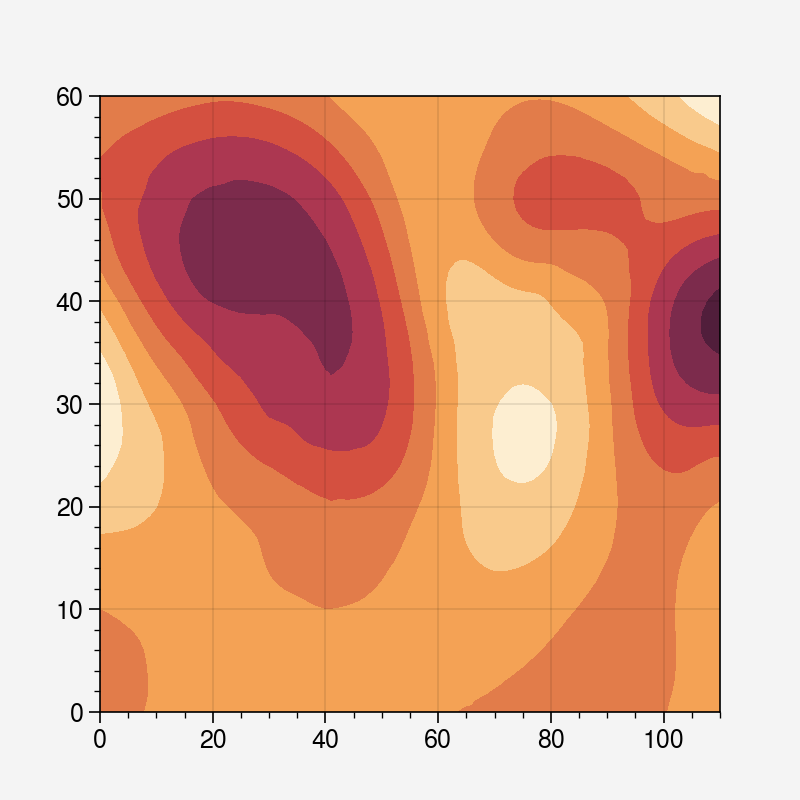

In [16]:
plt.contourf(ds_zanom['z'][0,:,:])

### EOFs &  PCs

In [17]:
coslat = np.cos(np.deg2rad(ds_zanom['lat'].values))
weights_array = np.sqrt(coslat)[:, np.newaxis]
ds_zanom['z']=ds_zanom['z']*weights_array
norm_z=np.sqrt((ds_zanom['z'].var(dim='time')).mean(dim=['lat','lon']))
ds_zanom['z']=ds_zanom['z']/norm_z
solver=MultivariateEof([ds_zanom['z'].values])
eof_list=solver.eofs(neofs=npcs,eofscaling=0)
np.shape(eof_list)

(1, 12, 61, 111)

In [18]:
eofs_ds_z500=xr.DataArray(eof_list[0][:]/weights_array,
                    coords={'eofnum': np.arange(npcs),
                            'lat': ds_zanom['lat'].values,
                            'lon': ds_zanom['lon'].values},
                            dims=['eofnum','lat','lon'])   
eofs_ds = eofs_ds_z500.to_dataset(name='z')
eofs_ds

<xarray.Dataset> Size: 651kB
Dimensions:  (eofnum: 12, lat: 61, lon: 111)
Coordinates:
  * eofnum   (eofnum) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float32 244B 10.0 11.0 12.0 13.0 14.0 ... 67.0 68.0 69.0 70.0
  * lon      (lon) float32 444B 210.0 211.0 212.0 213.0 ... 318.0 319.0 320.0
Data variables:
    z        (eofnum, lat, lon) float64 650kB 0.001342 0.001342 ... -0.05171

In [19]:
pcs = solver.pcs(npcs=npcs, pcscaling=0)
pcs.shape

(4728, 12)

In [20]:
variance_fractions = solver.varianceFraction(neigs=npcs)
variance_fractions.sum()*100

92.3564637377394

In [21]:
pcs_ds=xr.DataArray(pcs,
                    coords={'time': ds_zanom['time'].values,
                            'pcnum':np.arange(npcs)},
                            dims=['time','pcnum'])        
pcs_ds=pcs_ds.to_dataset(name='pcs').compute()

### Kmeans Cluster

In [22]:
kmeans4 = KMeans(n_clusters=4,random_state=1,init='random',n_init=10000,algorithm='elkan')
kmeans4.fit(pcs_ds['pcs'])
y_kmeans4=kmeans4.predict(pcs_ds['pcs'])

In [23]:
labels = np.array(kmeans4.labels_)
labels

array([3, 3, 3, ..., 1, 1, 1], dtype=int32)

In [24]:
# Create an xarray Dataset
ds_cluster = xr.Dataset(
    {"cluster": (["time"], labels)},  # "index" is the dimension name
    coords={"time": ds_zanom['time']}  # Coordinate for the dimension
)
ds_cluster

<xarray.Dataset> Size: 113kB
Dimensions:    (time: 4728)
Coordinates:
    level      (time) int32 19kB dask.array<chunksize=(4728,), meta=np.ndarray>
    dayofyear  (time) int64 38kB dask.array<chunksize=(4728,), meta=np.ndarray>
  * time       (time) datetime64[ns] 38kB 1981-01-01 1981-01-02 ... 2019-12-31
Data variables:
    cluster    (time) int32 19kB 3 3 3 3 3 3 3 3 3 1 1 ... 2 2 2 2 2 2 2 1 1 1 1

In [25]:
# Save to NetCDF
ds_cluster.to_netcdf(out_path+'kmeans_4cluster_'+seas+'_1981-2019_NA.nc')

PermissionError: [Errno 13] Permission denied: '/data/esplab/scratch/kpegion/obs_seus/wr_z500/kmeans_4cluster_DJF_1981-2019_NA.nc'